In [26]:
from pathlib import Path
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import pickle
import altair as alt

### Load the file output by the process_icesat2.ipynb

In [2]:
atl06sr_gdf = pickle.load(open('../../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked.pkl', 'rb'))

In [3]:
sierras = gpd.read_file('../../data/misc/sierras_polygon_gmba.geojson')

In [4]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2019, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [5]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

### Get timeseries of median/average reanalysis snow depth:

In [6]:
swe_sca_ds = swe_sca_ds.rename({'y': 'lat', 'x': 'lon'})

In [7]:
swe_sca_ds_allyrs = swe_sca_ds_allyrs.rename({'y': 'lat', 'x': 'lon'})

### Define elevation and slope bins: 

In [16]:
elev_min = np.arange(1000, 4400, 200)
elev_max = np.arange(1200, 4600, 200)
elev_max

array([1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000, 3200,
       3400, 3600, 3800, 4000, 4200, 4400])

In [17]:
slope_min = np.arange(0, 70, 10)
slope_max = np.arange(10, 80, 10)
slope_max

array([10, 20, 30, 40, 50, 60, 70])

### Create dataframe of metrics for plotting:

In [217]:
atl06sr_gdf.columns

Index(['segment_watermask', 'segment_snowcover', 'pflags', '3dep.value',
       'region', '3dep.deriv.slope', 'gt', 'n_fit_photons',
       'w_surface_window_final', '3dep.fileid', 'rgt', 'rms_misfit',
       '3dep.deriv.count', '3dep.deriv.aspect', 'h_mean', 'dh_fit_dx', 'x_atc',
       'h_sigma', 'spot', 'y_atc', 'urban_flag', '3dep.time_ns',
       'beam_azimuth', 'srcid', 'segment_landcover', 'cycle', 'photon_start',
       'geometry', 'time', 'slope_count', 'slope', 'aspect', 'file', 'value',
       'time_acq', 'doy', 'decyear', 'dowy', 'acqdate', 'reanalysis_swe',
       'reanalysis_sca', 'reanalysis_sd', 'icesat2_3dep_dif', 'dif_plus',
       'offset_sd', 'mask'],
      dtype='object')

In [163]:
# all slopes:

x_medians1 = []
subset_labels1 = []
elev1 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values
    if len(subset)>100:
        x_medians1.append(np.nanmedian(subset))
        subset_labels1.append('all_by_elevation')
    else:
        x_medians1.append(np.nan)
        subset_labels1.append('all_by_elevation')

y_medians1 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values
    if len(subset)>100:
        y_medians1.append(np.nanmedian(subset))
    else:
        y_medians1.append(np.nan)

# md_1 = []
# for x_min, x_max in zip(elev_min, elev_max):
#     md_1.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values) - 
#                               np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

# under 20 slope:
x_medians2 = []
subset_labels2 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values
    if len(subset)>100:
        x_medians2.append(np.nanmedian(subset))
        subset_labels2.append('under_20slope')
    else:
        x_medians2.append(np.nan)
        subset_labels2.append('under_20slope')

y_medians2 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values
    if len(subset)>100:    
        y_medians2.append(np.nanmedian(subset))
    else:
        y_medians2.append(np.nan)

# md_2 = []
# for x_min, x_max in zip(elev_min, elev_max):
#     md_.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values) - 
#                               np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

# by slope:
x_medians3 = []
subset_labels3 = []
for x_min, x_max in zip(slope_min, slope_max):
    x_medians3.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))
    subset_labels3.append('median_by_slope')

y_medians3 = []
for x_min, x_max in zip(slope_min, slope_max):
    y_medians3.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))

residuals3 = []
residuals_n = []
residuals_labels3 = []
for x_min, x_max in zip(slope_min, slope_max):
    subset_is2 = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values
    subset_r = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values
    
    residuals3.append(np.nanmedian(subset_is2) - np.nanmedian(subset_r))
    residuals_n.append(len(subset_is2))
    residuals_labels3.append('residuals_by_slope')


### do the same calcs but using the snow mask instead of fsca>0.9

In [219]:
# all slopes:

x_medians1 = []
subset_labels1 = []
elev1 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values
    if len(subset)>100:
        x_medians1.append(np.nanmedian(subset))
        subset_labels1.append('all_by_elevation')
    else:
        x_medians1.append(np.nan)
        subset_labels1.append('all_by_elevation')

y_medians1 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values
    if len(subset)>100:
        y_medians1.append(np.nanmedian(subset))
    else:
        y_medians1.append(np.nan)

# md_1 = []
# for x_min, x_max in zip(elev_min, elev_max):
#     md_1.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values) - 
#                               np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

# under 20 slope:
x_medians2 = []
subset_labels2 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values
    if len(subset)>100:
        x_medians2.append(np.nanmedian(subset))
        subset_labels2.append('under_20slope')
    else:
        x_medians2.append(np.nan)
        subset_labels2.append('under_20slope')

y_medians2 = []
for x_min, x_max in zip(elev_min, elev_max):
    subset = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values
    if len(subset)>100:    
        y_medians2.append(np.nanmedian(subset))
    else:
        y_medians2.append(np.nan)

# md_2 = []
# for x_min, x_max in zip(elev_min, elev_max):
#     md_.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values) - 
#                               np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

# by slope:
residuals3 = []
residuals_n = []
residuals_labels3 = []
for x_min, x_max in zip(slope_min, slope_max):
    subset_is2 = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values
    subset_r = atl06sr_gdf.loc[(atl06sr_gdf['mask']==1) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values
    
    residuals3.append(np.nanmedian(subset_is2) - np.nanmedian(subset_r))
    residuals_n.append(len(subset_is2))
    residuals_labels3.append('residuals_by_slope')


In [220]:
elev_max_list = elev_max.tolist()

scatter_data = pd.DataFrame({
    'x_medians': x_medians1 + x_medians2,
    'y_medians': y_medians1 + y_medians2,
    'labels': subset_labels1 + subset_labels2,
    'elevation_bin': elev_max_list + elev_max_list
})

In [221]:
residual_data = pd.DataFrame({
    'residuals': residuals3,
    'sample_size': residuals_n,
    'slope_bin': slope_max,
    'labels': residuals_labels3,
    'y_pos': [0.2, 0.2,0.2,0.2,0.2,0.2,0.2] #[1.6,1.3,1,0.7,0.4,0.1,-0.2]
})

residual_data['sign'] = np.where(residual_data['residuals'] >= 0, 'positive', 'negative')
residual_data['annotation'] = residual_data['residuals'].round(2).astype(str)
residual_data['sample_size_annotation'] = residual_data['sample_size'].astype(str)

In [222]:
all_bias = np.mean(scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'x_medians'] - 
                   scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'y_medians'])

slope_bias = np.mean(scatter_data.loc[(scatter_data['labels']=='under_20slope'),'x_medians'] -
                     scatter_data.loc[(scatter_data['labels']=='under_20slope'),'y_medians'])

all_cor = np.corrcoef(scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'x_medians'].dropna(),
                        scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'y_medians'].dropna())[0,1]

slope_cor = np.corrcoef(scatter_data.loc[(scatter_data['labels']=='under_20slope'),'x_medians'].dropna(),
                        scatter_data.loc[(scatter_data['labels']=='under_20slope'),'y_medians'].dropna())[0,1]

all_rmse = np.sqrt(np.nanmean((scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'x_medians'] -
                                    scatter_data.loc[(scatter_data['labels']=='all_by_elevation'),'y_medians'])**2))
slope_rmse = np.sqrt(np.nanmean((scatter_data.loc[(scatter_data['labels']=='under_20slope'),'x_medians'] -
                                    scatter_data.loc[(scatter_data['labels']=='under_20slope'),'y_medians'])**2))

In [223]:
metrics_data = pd.DataFrame({
    'metric': [all_bias, slope_bias, all_cor, slope_cor, all_rmse, slope_rmse],
    'metric_label':['bias', 'bias', 'correlation', 'correlation', 'rmse', 'rmse'],
    'labels': ['all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope', 'all_by_elevation', 'under_20slope'],
    'x_pos': [0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    'y_pos': [-0.01,-0.01,-0.08, -0.08, -0.15, -0.15]
})

metrics_data['metric_2f'] = metrics_data['metric'].round(2)

### Plot scatters and bar plots by elevation and slope:

In [160]:
import matplotlib as mpl
cmap = mpl.colormaps['managua'].resampled(256)
colors = [mpl.colors.rgb2hex(cmap(i/(256-1))) for i in range(256)]


In [216]:
x = np.linspace(0, 1.4, 100) # Creates 100 points between x_min and x_max
y = x
line_data = pd.DataFrame({
    'x': [-0.2, 1.4],
    'y': [-0.2, 1.4]
})

scatter_chart = alt.layer(alt.Chart(scatter_data[scatter_data['labels']=='all_by_elevation']).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.3])),
    y=alt.Y('y_medians:Q', title='Sampled Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.3])),
    color=alt.Color('elevation_bin:Q', title='Elevation (m)', scale=alt.Scale(range=colors), legend=None)
).properties(
    title='All slopes'
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')) + \
    alt.Chart(metrics_data[metrics_data['labels']=='all_by_elevation']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N' #'metric_label:N'+': '+
    ) 

scatter_chart_slope = alt.layer(alt.Chart(scatter_data[scatter_data['labels']=='under_20slope']).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.4])),
    y=alt.Y('y_medians:Q', title=None, scale=alt.Scale(domain=[-0.2, 1.4])),
    color=alt.Color('elevation_bin:Q', scale=alt.Scale(range=colors))
    # .legend(orient="none", # Hide default legend position
    #     legendX=600,    # X position in pixels from left
    #     legendY=75)
).properties(
    title='Only slopes under 20 degrees'
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')
)+ \
    alt.Chart(metrics_data[metrics_data['labels']=='under_20slope']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N'
    )

residuals_chart = alt.Chart(residual_data).mark_bar(color = '#E7969C').encode(
    x=alt.X('slope_bin:O', title='Slope Bin (degrees)'),
    y=alt.Y('residuals:Q', title='Residuals (m)', scale=alt.Scale(domain=[-10.25,1.])),
    #color=alt.Color('sign:N', legend=None, scale=alt.Scale(domain=['negative', 'positive'], range=['#8D0051', '#E9AC5B']))
).properties(
    width=200
) + \
    alt.Chart(residual_data).mark_text(
        align='center', angle=90, color='#8D0051',baseline='bottom', dy=7, dx=25,fontSize=15).encode(
        x='slope_bin:O', y='residuals:Q', text='annotation:Q'
        ) + \
    alt.Chart(residual_data).mark_text(
        align='right', angle=90, color='#8D0051',baseline='bottom', dy=7, dx=0,fontSize=15).encode(
        x='slope_bin:O', y='y_pos:Q', text='sample_size_annotation:Q'
        )

combined_2_charts = alt.hconcat(scatter_chart, scatter_chart_slope)


combined = alt.hconcat(combined_2_charts, residuals_chart).configure_axis(
    grid=False,  # This removes the grid lines
    labelFontSize=14,  # Set default label font size
    titleFontSize=16   # Set default title font size
) 
combined

alt.HConcatChart(...)

In [225]:
# same plot as above but using mask==1 instead of reanalysis_sca>0.9

x = np.linspace(0, 1.4, 100) # Creates 100 points between x_min and x_max
y = x
line_data = pd.DataFrame({
    'x': [-0.2, 1.4],
    'y': [-0.2, 1.4]
})

scatter_chart = alt.layer(alt.Chart(scatter_data[scatter_data['labels']=='all_by_elevation']).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.3])),
    y=alt.Y('y_medians:Q', title='Sampled Reanalysis Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.3])),
    color=alt.Color('elevation_bin:Q', title='Elevation (m)', scale=alt.Scale(range=colors))
).properties(
    title='All slopes'
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')) + \
    alt.Chart(metrics_data[metrics_data['labels']=='all_by_elevation']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N' #'metric_label:N'+': '+
    ) 

scatter_chart_slope = alt.layer(alt.Chart(scatter_data[scatter_data['labels']=='under_20slope']).mark_circle(size=100, stroke='black', opacity=0.8).encode(
    x=alt.X('x_medians:Q', title='ICESat-2 Snow Depth (m)', scale=alt.Scale(domain=[-0.2, 1.4])),
    y=alt.Y('y_medians:Q', title=None, scale=alt.Scale(domain=[-0.2, 1.4])),
    color=alt.Color('elevation_bin:Q', scale=alt.Scale(range=colors))
    # .legend(orient="none", # Hide default legend position
    #     legendX=600,    # X position in pixels from left
    #     legendY=75)
).properties(
    title='Only slopes under 20 degrees'
),
alt.Chart(line_data).mark_line(color='red', strokeDash=[5, 5]).encode(
    x='x:Q',
    y='y:Q')
)+ \
    alt.Chart(metrics_data[metrics_data['labels']=='under_20slope']).mark_text(
        align='left',
        baseline='middle',
        dx=5,
        fontSize=15
    ).transform_calculate(
        annotation_text = "datum.metric_label + ': ' + datum.metric_2f"
    ).encode(
        x=alt.X('x_pos:Q'),
        y=alt.Y('y_pos:Q'),
        text='annotation_text:N'
    )

residuals_chart = alt.Chart(residual_data).mark_bar(color = '#E7969C').encode(
    x=alt.X('slope_bin:O', title='Slope Bin (degrees)'),
    y=alt.Y('residuals:Q', title='Residuals (m)', scale=alt.Scale(domain=[-10.25,1.])),
    #color=alt.Color('sign:N', legend=None, scale=alt.Scale(domain=['negative', 'positive'], range=['#8D0051', '#E9AC5B']))
).properties(
    width=200
) + \
    alt.Chart(residual_data).mark_text(
        align='center', angle=90, color='#8D0051',baseline='bottom', dy=7, dx=25,fontSize=15).encode(
        x='slope_bin:O', y='residuals:Q', text='annotation:Q'
        ) + \
    alt.Chart(residual_data).mark_text(
        align='right', angle=90, color='black',baseline='bottom', dy=7, dx=0,fontSize=15).encode(
        x='slope_bin:O', y='y_pos:Q', text='sample_size_annotation:Q'
        )

combined_2_charts = alt.hconcat(scatter_chart, scatter_chart_slope)


combined = alt.hconcat(combined_2_charts, residuals_chart).configure_axis(
    grid=False,  # This removes the grid lines
    labelFontSize=14,  # Set default label font size
    titleFontSize=16   # Set default title font size
) 
combined

alt.HConcatChart(...)

### Run an experiment to sample ICESat-2 data on one date at different sample sizes:

In [226]:
atl06sr_gdf.columns

Index(['segment_watermask', 'segment_snowcover', 'pflags', '3dep.value',
       'region', '3dep.deriv.slope', 'gt', 'n_fit_photons',
       'w_surface_window_final', '3dep.fileid', 'rgt', 'rms_misfit',
       '3dep.deriv.count', '3dep.deriv.aspect', 'h_mean', 'dh_fit_dx', 'x_atc',
       'h_sigma', 'spot', 'y_atc', 'urban_flag', '3dep.time_ns',
       'beam_azimuth', 'srcid', 'segment_landcover', 'cycle', 'photon_start',
       'geometry', 'time', 'slope_count', 'slope', 'aspect', 'file', 'value',
       'time_acq', 'doy', 'decyear', 'dowy', 'acqdate', 'reanalysis_swe',
       'reanalysis_sca', 'reanalysis_sd', 'icesat2_3dep_dif', 'dif_plus',
       'offset_sd', 'mask'],
      dtype='object')

In [227]:
atl06sr_gdf['acqdate_dt'] = pd.to_datetime(atl06sr_gdf['acqdate'])

In [240]:
atl06sr_gdf['is2_r_diff'] = atl06sr_gdf['icesat2_3dep_dif'] - atl06sr_gdf['reanalysis_sd']

In [315]:
highlight_date = [pd.to_datetime('2021-04-01'), pd.to_datetime('2021-04-07')]

In [269]:
atl06_highlight_data = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['acqdate_dt'].isin([highlight_date[0]])) & (atl06sr_gdf['slope']<20)]

In [316]:
atl06_highlight_data2 = atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['acqdate_dt'].isin([highlight_date[1]])) & (atl06sr_gdf['slope']<20)]

In [270]:
sample1 = atl06_highlight_data['is2_r_diff'].sample(n=10)

In [244]:
np.nanmedian(sample1)

np.float64(-1.7496050983090754)

<Axes: >

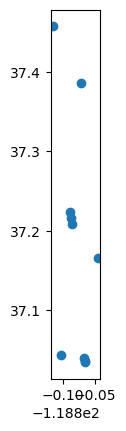

In [233]:
sample1.plot()

<Axes: >

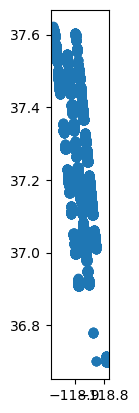

In [234]:
atl06_highlight_data.plot()

### Test for one date:

In [299]:
numbers_and_repeats = [(10, 100), (25, 100), (50, 100), (75, 100), (100, 100) , (150, 100) , (200, 100), (250, 100), (300, 100), (350, 100), (400, 100), (450, 100), (500, 100)] # (number, repetitions)
repeated_list = []

for num, reps in numbers_and_repeats:
    repeated_list.extend([num] * reps)

numbers_and_repeats

sample_num = [i for _ in range(len(numbers_and_repeats)) for i in range(1, 101)]

In [304]:
sample_ranges = [10, 25, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]

sample_df = pd.DataFrame({'sample_size': repeated_list, 'sample_num': sample_num})

sample_df['median'] = np.nan

for sample_size in sample_df['sample_size'].unique():
    sampled_values_ens = []
    for num in range(100):
        sample = atl06_highlight_data['is2_r_diff'].sample(n=sample_size)
        sample_median = np.nanmedian(sample.values)
        #sampled_values_ens.append(sample_median)
        sample_df.loc[(sample_df['sample_size']==sample_size) & (sample_df['sample_num']==num), 'median'] = sample_median

In [310]:
sample_chart = alt.Chart(sample_df).mark_point().encode(
    x=alt.X('sample_size:Q', title='Sample Size'),
    y=alt.Y('median:Q', title='Median ICESat-2 - Reanalysis Snow Depth Difference (m)', scale=alt.Scale(domain=[-1, 1])),
    color=alt.Color('sample_size:O', title='Sample Size', scale=alt.Scale(scheme='rainbow'))
).properties(
    title='Effect of Sample Size on Median Snow Depth Difference Estimate'
)

sample_chart

alt.Chart(...)

In [311]:
sampled_values_10 = []
for _ in range(100):
    sample = atl06_highlight_data['is2_r_diff'].sample(n=10)
    sample_median = np.nanmedian(sample.values)
    sampled_values_10.append(sample_median)

sampled_values_20 = []
for _ in range(100):
    sample = atl06_highlight_data['is2_r_diff'].sample(n=20)
    sample_median = np.nanmedian(sample.values)
    sampled_values_20.append(sample_median)

sampled_values_50 = []
for _ in range(100):
    sample = atl06_highlight_data['is2_r_diff'].sample(n=50)
    sample_median = np.nanmedian(sample.values)
    sampled_values_50.append(sample_median)

sampled_values_100 = []
for _ in range(100):
    sample = atl06_highlight_data['is2_r_diff'].sample(n=100)
    sample_median = np.nanmedian(sample.values)
    sampled_values_100.append(sample_median)

sampled_values_1000 = []
for _ in range(100):
    sample = atl06_highlight_data['is2_r_diff'].sample(n=1000)
    sample_median = np.nanmedian(sample.values)
    sampled_values_1000.append(sample_median)

sampled_values_1500 = []
for _ in range(100):
    sample = atl06_highlight_data['is2_r_diff'].sample(n=1500)
    sample_median = np.nanmedian(sample.values)
    sampled_values_5000.append(sample_median)

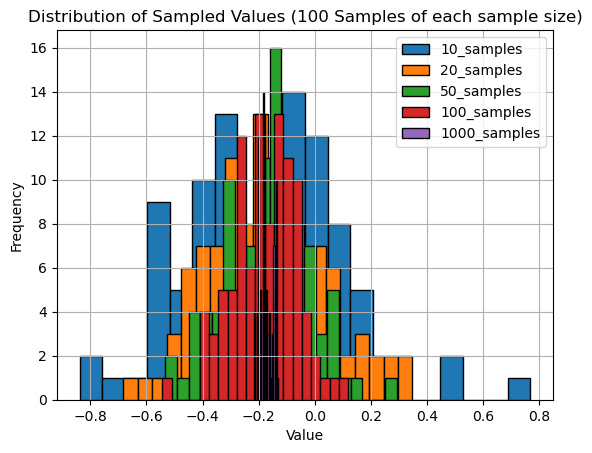

In [314]:
fig, ax = plt.subplots()
plt.hist(sampled_values_10, bins=20, edgecolor='black', label='10_samples')
plt.hist(sampled_values_20, bins=20, edgecolor='black', label='20_samples')
plt.hist(sampled_values_50, bins=20, edgecolor='black', label='50_samples')
plt.hist(sampled_values_100, bins=20, edgecolor='black', label='100_samples')
plt.hist(sampled_values_1000, bins=20, edgecolor='black', label='1000_samples')
#plt.hist(sampled_values_1500, bins=20, edgecolor='black', label='1500_samples')
plt.title('Distribution of Sampled Values (100 Samples of each sample size)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()
plt.show()

### Test for a second date:

In [317]:
numbers_and_repeats = [(10, 100), (25, 100), (50, 100), (75, 100), (100, 100) , (150, 100) , (200, 100), (250, 100), (300, 100), (350, 100), (400, 100), (450, 100), (500, 100)] # (number, repetitions)
repeated_list = []

for num, reps in numbers_and_repeats:
    repeated_list.extend([num] * reps)

numbers_and_repeats

sample_num = [i for _ in range(len(numbers_and_repeats)) for i in range(1, 101)]

In [318]:
sample_ranges = [10, 25, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500]

sample_df = pd.DataFrame({'sample_size': repeated_list, 'sample_num': sample_num})

sample_df['median'] = np.nan

for sample_size in sample_df['sample_size'].unique():
    sampled_values_ens = []
    for num in range(100):
        sample = atl06_highlight_data2['is2_r_diff'].sample(n=sample_size)
        sample_median = np.nanmedian(sample.values)
        #sampled_values_ens.append(sample_median)
        sample_df.loc[(sample_df['sample_size']==sample_size) & (sample_df['sample_num']==num), 'median'] = sample_median

In [319]:
sample_chart = alt.Chart(sample_df).mark_point().encode(
    x=alt.X('sample_size:Q', title='Sample Size'),
    y=alt.Y('median:Q', title='Median ICESat-2 - Reanalysis Snow Depth Difference (m)', scale=alt.Scale(domain=[-1, 1])),
    color=alt.Color('sample_size:O', title='Sample Size', scale=alt.Scale(scheme='rainbow'))
).properties(
    title='Effect of Sample Size on Median Snow Depth Difference Estimate'
)

sample_chart

alt.Chart(...)

In [320]:
sampled_values_10 = []
for _ in range(100):
    sample = atl06_highlight_data2['is2_r_diff'].sample(n=10)
    sample_median = np.nanmedian(sample.values)
    sampled_values_10.append(sample_median)

sampled_values_20 = []
for _ in range(100):
    sample = atl06_highlight_data2['is2_r_diff'].sample(n=20)
    sample_median = np.nanmedian(sample.values)
    sampled_values_20.append(sample_median)

sampled_values_50 = []
for _ in range(100):
    sample = atl06_highlight_data2['is2_r_diff'].sample(n=50)
    sample_median = np.nanmedian(sample.values)
    sampled_values_50.append(sample_median)

sampled_values_100 = []
for _ in range(100):
    sample = atl06_highlight_data2['is2_r_diff'].sample(n=100)
    sample_median = np.nanmedian(sample.values)
    sampled_values_100.append(sample_median)

sampled_values_1000 = []
for _ in range(100):
    sample = atl06_highlight_data2['is2_r_diff'].sample(n=1000)
    sample_median = np.nanmedian(sample.values)
    sampled_values_1000.append(sample_median)

sampled_values_1500 = []
for _ in range(100):
    sample = atl06_highlight_data2['is2_r_diff'].sample(n=1500)
    sample_median = np.nanmedian(sample.values)
    sampled_values_5000.append(sample_median)

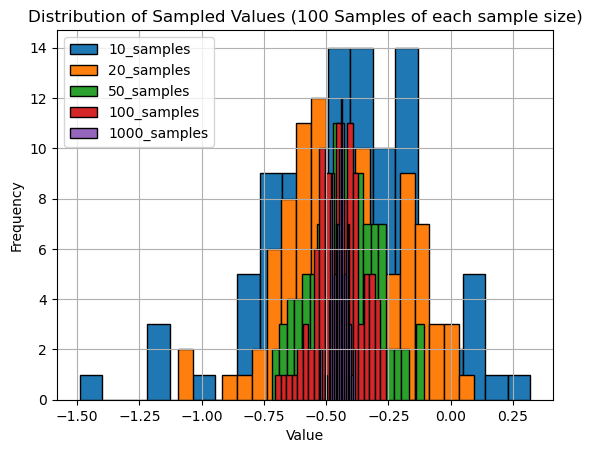

In [321]:
fig, ax = plt.subplots()
plt.hist(sampled_values_10, bins=20, edgecolor='black', label='10_samples')
plt.hist(sampled_values_20, bins=20, edgecolor='black', label='20_samples')
plt.hist(sampled_values_50, bins=20, edgecolor='black', label='50_samples')
plt.hist(sampled_values_100, bins=20, edgecolor='black', label='100_samples')
plt.hist(sampled_values_1000, bins=20, edgecolor='black', label='1000_samples')
#plt.hist(sampled_values_1500, bins=20, edgecolor='black', label='1500_samples')
plt.title('Distribution of Sampled Values (100 Samples of each sample size)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()
plt.show()

### Exploratory plots at different slopes and snow cover amounts:

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Text(0.5, 1.0, 'By Elevation, with all slopes and fsca > 0.9')

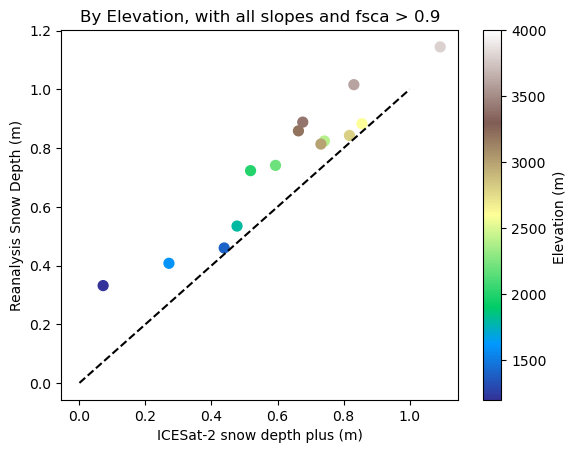

In [ ]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='terrain', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m) ')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation, with all slopes and fsca > 0.9')

Text(0.5, 1.0, 'By Elevation, with all slopes and all fsca values')

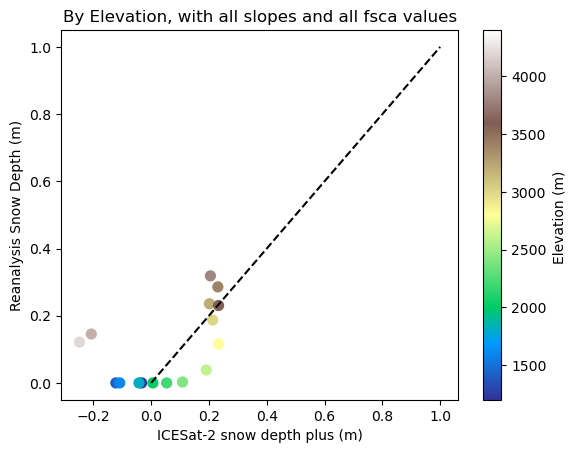

In [ ]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='terrain', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m) ')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation, with all slopes and all fsca values')

(-0.5, 1.3)

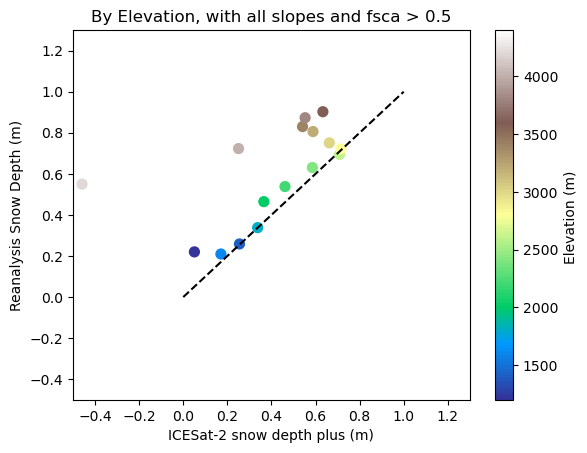

In [ ]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='terrain', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m) ')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation, with all slopes and fsca > 0.5')
plt.xlim(-0.5, 1.3)
plt.ylim(-0.5, 1.3)

(0.0, 1.3)

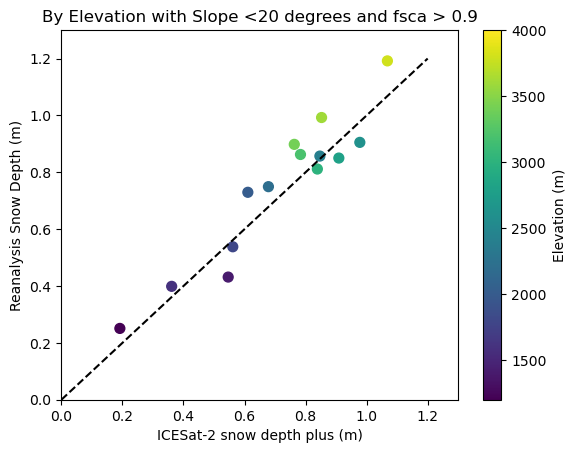

In [ ]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1.2, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <20 degrees and fsca > 0.9')
plt.xlim(0, 1.3)
plt.ylim(0, 1.3)

(0.0, 1.3)

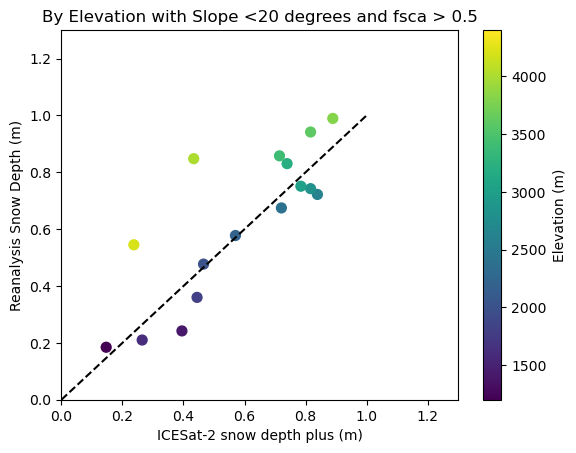

In [ ]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <20 degrees and fsca > 0.5')
plt.xlim(0, 1.3)
plt.ylim(0, 1.3)

(0.0, 1.3)

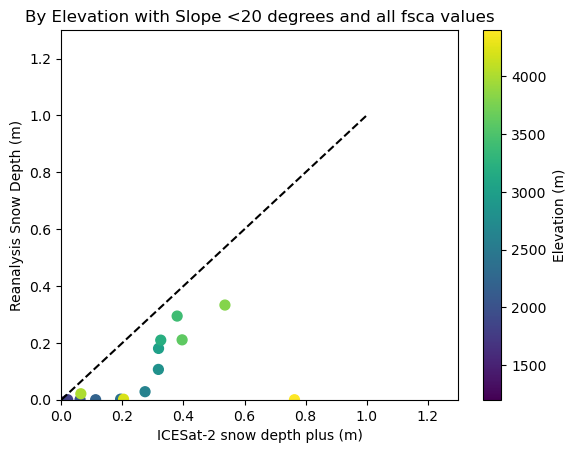

In [ ]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <20 degrees and all fsca values')
plt.xlim(0, 1.3)
plt.ylim(0, 1.3)

### Plot slope:

Text(0.5, 1.0, 'By Slope, with all Elevations and fsca >0.9')

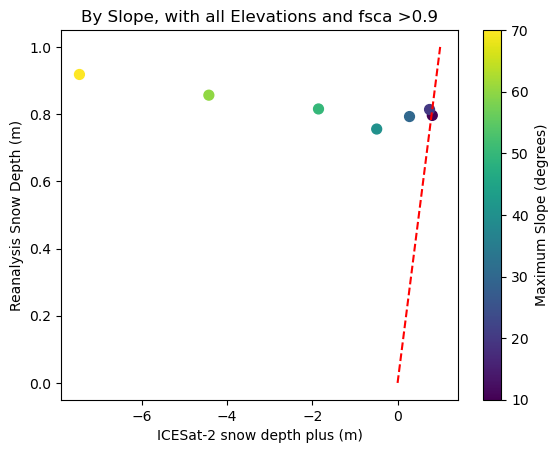

In [ ]:
x_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=slope_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Maximum Slope (degrees)')

plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Slope, with all Elevations and fsca >0.9')

Text(0.5, 1.0, 'By Slope, with all Elevations and fsca >0.5')

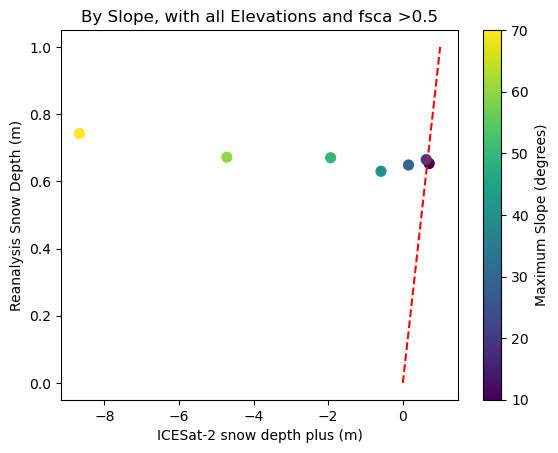

In [ ]:
x_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=slope_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Maximum Slope (degrees)')

plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Slope, with all Elevations and fsca >0.5')

Text(0.5, 1.0, 'By Slope, with all Elevations and all fsca values')

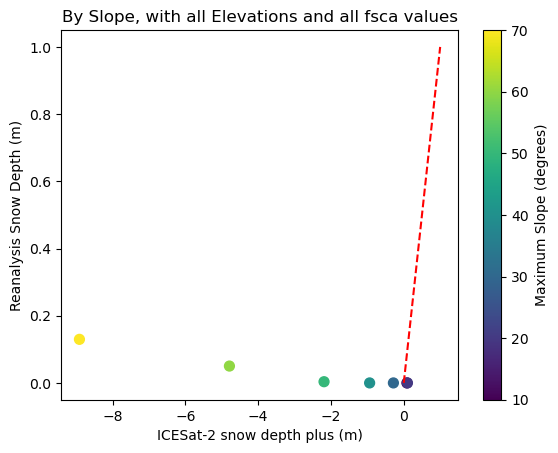

In [ ]:
x_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=slope_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Maximum Slope (degrees)')

plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Slope, with all Elevations and all fsca values')